# LOAD LIBRARIES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import json
from datetime import datetime
from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold, GridSearchCV, PredefinedSplit
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from diive.core.io.files import load_parquet

# CONFIGURATION

In [2]:
START_DATE, END_DATE = '2023-11-08', '2025-06-05'
TARGET_FLUX = 'NEE'
N_FOLDS = 10
MODEL_TYPE = 'XGBoost'  # Options: 'RandomForest' or 'XGBoost'
CROSSVAL_SPLIT = 'time_blocks_eliza' # options: 'shuffle' or 'kfold' or 'custom_time_blocks' or 'time_blocks_eliza'
PARCEL_CERTAIN = False
LOG_TRANSFORM = False
ADD_ID = True
UNDERSAMPLE = False
DAY_NIGHT = 'NIGHT'
ADD_TRT = False

# LOAD DATA

In [3]:
data_main = fluxes = load_parquet(filepath=r"81.1.1_GapFillingDataset.parquet")
data_main = data_main.loc[START_DATE:END_DATE].copy()

# Add an id column to account for the proximity of values as the timestamp is continuous without gaps
if ADD_ID:
    data_main['id'] = range(0, len(data_main))

# Add trt variable
if ADD_TRT:
    data_main['trt'] = data_main['parcel'].map({'A': 0, 'B': 1}).fillna(0.5)
data_main

data_main

Loaded .parquet file 81.1.1_GapFillingDataset.parquet (0.520 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 


,NEE_L3.3_CUT_50_QCF,FN2O_L3.3_CUT_50_QCF,FCH4_L3.3_CUT_50_QCF,NEE_L3.3_CUT_50_QCF0,FN2O_L3.3_CUT_50_QCF0,FCH4_L3.3_CUT_50_QCF0,parcel,parcel_certainty,SW_IN_POT,prec,ta,ppfd,sw_in,rh,timesince_prec,...,wfps_0.15_gfXG_diff12h,wfps_0.15_gfXG_diff24h,wfps_0.3_gfXG_diff6h,wfps_0.3_gfXG_diff12h,wfps_0.3_gfXG_diff24h,n_decay_linear,n_decay_logistic,n_decay_exponential,n_decay_lognormal,n_decay_timed,timesince_fert,fert_timed,LAI,can_height,id
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-08 00:15:00,NaN,-0.111997,-3.231648,NaN,NaN,-3.231648,B,certain,0.0,0.0,5.333333,0.0,0.0,79.833333,12.0,...,-0.188894,0.055964,-1.641550,-0.086146,0.576043,0.0,0.0,2.185170,0.986663,29.0,22.0,1.0,0.300700,5.004348,0
2023-11-08 00:45:00,NaN,0.100302,NaN,NaN,0.100302,NaN,B,certain,0.0,0.0,5.966667,0.0,0.0,77.500000,13.0,...,0.009568,0.016644,-2.340741,0.001028,0.291943,0.0,0.0,2.179702,0.983564,29.0,22.0,1.0,0.300704,5.004376,1
2023-11-08 01:15:00,NaN,0.239428,NaN,NaN,0.239428,NaN,B,certain,0.0,0.0,5.833333,0.0,0.0,77.366667,14.0,...,0.084459,0.138010,-0.829823,0.242660,0.618842,0.0,0.0,2.174248,0.980476,29.0,22.0,1.0,0.300709,5.004405,2
2023-11-08 01:45:00,NaN,-0.184917,6.746138,NaN,NaN,NaN,B,certain,0.0,0.0,5.866667,0.0,0.0,77.100000,15.0,...,-0.023746,0.307449,-0.724752,0.260016,0.686303,0.0,0.0,2.168807,0.977400,29.0,22.0,1.0,0.300714,5.004433,3
2023-11-08 02:15:00,NaN,0.358358,3.168362,NaN,0.358358,3.168362,B,certain,0.0,0.0,5.766667,0.0,0.0,77.166667,16.0,...,-0.028905,0.178615,-0.724348,0.032634,0.695635,0.0,0.0,2.163380,0.974334,29.0,22.0,1.0,0.300718,5.004462,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-05 21:45:00,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,0.0,15.833333,0.0,0.0,84.166667,22.0,...,-1.916712,-1.061214,-4.208609,-5.629534,-3.817729,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27643
2025-06-05 22:15:00,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,0.0,15.733333,0.0,0.0,83.833333,23.0,...,-1.879544,-0.962736,-4.909742,-6.854152,-4.700644,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27644
2025-06-05 22:45:00,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,0.0,16.200000,0.0,0.0,78.066667,24.0,...,-1.739450,-0.961502,-4.913663,-6.580284,-4.667567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27645


# SUBSET DAY/NIGHT

In [4]:
if DAY_NIGHT == 'DAY':
    data_main = data_main[data_main['sw_in'] > 20].copy()
else:
    data_main = data_main[data_main['sw_in'] <= 20].copy()

# CLEAN DATA

In [5]:
TARGET = f'{TARGET_FLUX}_L3.3_CUT_50_QCF0'
print(f'The target variable is {TARGET}')

mean_nan_size = (
    data_main[TARGET]
    .isna()
    .ne(data_main[TARGET].isna().shift())
    .cumsum()
    .where(data_main[TARGET].isna())
    .dropna()
    .value_counts()
    .mean()
)
print("\nMean size of consecutive NaNs in the target variable:", mean_nan_size)

# Remove NAs
data = data_main[data_main[TARGET].notna()].copy()

# Keep only data where we are sure about parcel attribution
if PARCEL_CERTAIN:
    data = data[data['parcel_certainty'] == 'certain'].copy()
    print('\nKeeping only data when we are highly confident on the parcel attribution')

# Remove any flux variable with target flux except for the target itself
to_drop = [col for col in data.columns if TARGET_FLUX in col]
# Leave the target!
to_drop.remove(TARGET)
data.drop(columns=to_drop, inplace=True)

data

The target variable is NEE_L3.3_CUT_50_QCF0

Mean size of consecutive NaNs in the target variable: 7.809669992325403


,FN2O_L3.3_CUT_50_QCF,FCH4_L3.3_CUT_50_QCF,NEE_L3.3_CUT_50_QCF0,FN2O_L3.3_CUT_50_QCF0,FCH4_L3.3_CUT_50_QCF0,parcel,parcel_certainty,SW_IN_POT,prec,ta,ppfd,sw_in,rh,timesince_prec,vpd,...,wfps_0.15_gfXG_diff12h,wfps_0.15_gfXG_diff24h,wfps_0.3_gfXG_diff6h,wfps_0.3_gfXG_diff12h,wfps_0.3_gfXG_diff24h,n_decay_linear,n_decay_logistic,n_decay_exponential,n_decay_lognormal,n_decay_timed,timesince_fert,fert_timed,LAI,can_height,id
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-22 15:15:00,-0.120498,14.564763,1.427440,NaN,NaN,A,certain,277.0860,0.000,3.160000,32.345077,16.666667,91.736666,8.0,0.063359,...,-0.109809,0.746184,-0.980362,0.760726,1.700008,0.0,0.0,0.0,0.0,0.0,30.0,0.0,0.456428,5.053577,702
2023-11-22 15:45:00,-0.000670,-10.744992,1.002807,-0.000670,NaN,A,certain,189.1070,0.000,2.983333,33.735705,17.333333,91.379999,9.0,0.065269,...,-0.057817,0.555294,-0.439485,0.204556,1.585453,0.0,0.0,0.0,0.0,0.0,30.0,0.0,0.456577,5.053685,703
2023-11-22 16:15:00,-0.124612,13.987140,1.405169,-0.124612,13.987140,A,certain,91.8094,0.017,2.693333,10.790348,6.333333,92.029999,0.0,0.059114,...,0.065239,0.717598,-0.121607,-0.801852,1.026511,0.0,0.0,0.0,0.0,0.0,30.0,0.0,0.456725,5.053794,704
2023-11-22 16:45:00,NaN,-8.235540,1.052631,NaN,NaN,A,certain,20.5151,0.017,2.593333,2.446582,2.333333,91.653332,0.0,0.061468,...,0.291490,0.747449,-0.333135,0.310568,0.461955,0.0,0.0,0.0,0.0,0.0,30.0,0.0,0.456873,5.053903,705
2023-11-22 17:15:00,0.166697,NaN,1.088705,0.166697,NaN,A,certain,0.0000,0.000,2.506667,0.000000,0.000000,90.480000,1.0,0.069676,...,0.345785,0.862861,-0.899240,-0.037856,0.678603,0.0,0.0,0.0,0.0,0.0,30.0,0.0,0.457022,5.054012,706
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-04 21:45:00,0.524032,2.489636,10.578562,0.524032,NaN,B,certain,0.0000,0.017,15.693333,0.000000,0.000000,82.700000,0.0,0.308913,...,-0.501428,-0.865616,-0.130630,-0.951387,-1.460515,0.0,0.0,0.0,0.0,0.0,30.0,0.0,4.389574,39.079782,27595
2025-06-04 22:15:00,NaN,-0.987718,9.416519,NaN,NaN,B,certain,0.0000,0.034,15.516667,0.000000,0.000000,84.423333,0.0,0.275008,...,-0.455520,-0.859899,-0.075635,-0.878298,-1.447001,0.0,0.0,0.0,0.0,0.0,30.0,0.0,4.393382,39.111514,27596
2025-06-04 22:45:00,-0.069384,2.160966,10.095010,-0.069384,2.160966,B,certain,0.0000,0.425,15.660000,0.000000,0.000000,83.819999,0.0,0.288298,...,-0.438437,-0.860283,-0.205865,-0.852473,-1.503494,0.0,0.0,0.0,0.0,0.0,30.0,0.0,4.397189,39.143246,27597


# SELECT FEATURES

In [6]:
# Import the best features
path = 'best_features_' + TARGET_FLUX + '_' + DAY_NIGHT + '_' + MODEL_TYPE + '.txt'
with open(path, 'r') as f:
    selected_features = [line.strip() for line in f]

# Other option is to define the best n features
# n_top = 23
# path = 'ranked_features_' + TARGET_FLUX + '_' + DAY_NIGHT + '_' + MODEL_TYPE + '.txt'
# with open(path, 'r') as f:
#     selected_features = [line.strip() for line in f][:n_top]

# Remove specific variables if you want
#to_remove = ('flux_nee', 'prec')
#selected_features = [c for c in selected_features if not c.startswith(to_remove)]

# selected_features = [
# 'timesince_soil_preparation',
# 'n_decay_timed',
# 'timesince_fert',
# 'wfps_0.05_gfXG_lag9h',
# 'wfps_0.05_gfXG_roll3hmean',
# 'ts_0.3_gfXG_lag6h_roll9hmean',
# 'GPP_U50_f_reddyproc_roll3hsum'
# ]

# Keep only the best feature set
data = data[selected_features + [TARGET]].copy()

data

,sw_in,timesince_soil_preparation,timesince_harvest,timesince_sowing,ts_0.15_gfXG_lag3h,ta_roll3hmean,ta_roll6hmean,ts_0.05_gfXG_roll6hmean,ts_0.15_gfXG_roll3hmean,ts_0.15_gfXG_roll6hmean,ts_0.15_gfXG_roll9hmean,ts_0.3_gfXG_roll3hmean,wfps_0.05_gfXG_roll3hmean,wfps_0.3_gfXG_roll3hmean,wfps_0.3_gfXG_roll6hmean,...,ts_0.3_gfXG_lag6h_roll9hmean,ts_0.3_gfXG_lag9h_roll6hmean,ts_0.3_gfXG_lag9h_roll9hmean,wfps_0.05_gfXG_lag6h_roll9hmean,wfps_0.05_gfXG_lag9h_roll9hmean,wfps_0.15_gfXG_lag3h_roll6hmean,wfps_0.15_gfXG_lag3h_roll9hmean,wfps_0.3_gfXG_lag6h_roll3hmean,ts_0.3_gfXG_diff12h,wfps_0.15_gfXG_diff24h,wfps_0.3_gfXG_diff24h,timesince_fert,fert_timed,id,NEE_L3.3_CUT_50_QCF0
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-22 15:15:00,16.666667,36.0,37.0,36.0,6.869158,3.051111,3.344722,3.808606,6.952958,6.587325,6.294733,7.535279,49.258021,45.095750,45.499152,...,7.972340,7.985643,8.019989,48.130769,47.911635,56.416565,56.312963,46.609992,-0.580641,0.746184,1.700008,30.0,0.0,702,1.427440
2023-11-22 15:45:00,17.333333,36.0,37.0,36.0,6.856443,3.048333,3.221667,3.831431,7.017529,6.717360,6.394192,7.476265,49.140697,45.418975,45.462528,...,7.956867,7.977492,8.012311,48.312845,47.884838,56.426473,56.317332,46.734472,-0.636331,0.555294,1.585453,30.0,0.0,703,1.002807
2023-11-22 16:15:00,6.333333,36.0,37.0,36.0,6.836869,3.006111,3.095000,3.850656,7.147379,6.888447,6.515586,7.440422,48.948094,45.722494,45.452394,...,7.941213,7.966017,8.002130,48.466064,47.825725,56.468509,56.324692,46.470009,-0.543200,0.717598,1.026511,30.0,0.0,704,1.405169
2023-11-22 16:45:00,2.333333,36.0,37.0,36.0,6.822034,2.943889,2.986944,3.865788,7.077169,6.951568,6.557413,7.428509,48.723270,45.810814,45.424633,...,7.926071,7.956247,7.993097,48.579144,47.807564,56.469249,56.330240,46.527426,-0.496225,0.747449,0.461955,30.0,0.0,705,1.052631
2023-11-22 17:15:00,0.000000,36.0,37.0,36.0,7.054002,2.850000,2.931944,3.821170,6.983021,6.926161,6.582199,7.510834,48.646204,45.966189,45.349696,...,7.910730,7.948376,7.984716,48.663029,47.851701,56.495168,56.337492,46.665390,0.131402,0.862861,0.678603,30.0,0.0,706,1.088705
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-04 21:45:00,0.000000,60.0,23.0,60.0,19.005000,16.010556,16.562500,19.715370,18.769259,18.912593,18.830957,17.299259,47.840280,45.270769,45.373525,...,16.980679,16.969259,17.054537,48.464595,48.668348,49.884240,49.966284,45.428747,0.318334,-0.865616,-1.460515,30.0,0.0,27595,10.578562
2025-06-04 22:15:00,0.000000,60.0,23.0,60.0,18.944445,15.874444,16.175000,19.418333,18.687037,18.867731,18.834938,17.299907,47.843746,45.229770,45.367222,...,16.980710,16.955463,17.034259,48.415514,48.644536,49.868172,49.945490,45.368111,0.353332,-0.859899,-1.447001,30.0,0.0,27596,9.416519
2025-06-04 22:45:00,0.000000,60.0,23.0,60.0,18.900000,15.769444,15.917222,19.131898,18.603426,18.813750,18.829475,17.294907,47.842013,45.189285,45.350067,...,16.985123,16.946296,17.017191,48.366121,48.616728,49.852705,49.924215,45.334049,0.368333,-0.860283,-1.503494,30.0,0.0,27597,10.095010


# IMBALANCE HANDLING

## UNDER SAMPLING

In [7]:
if UNDERSAMPLE:
    quantile_cutoff = 0.8
    cutoff_value = data[TARGET].quantile(quantile_cutoff)
    print(f'Undersampling target data below: {cutoff_value}')
    # Split and undersample
    upper = data[data[TARGET] > cutoff_value]
    lower = data[data[TARGET] <= cutoff_value]
    # Undersample
    lower_sampled = lower.sample(frac=0.5, random_state=42)
    # Combine
    data = pd.concat([upper, lower_sampled]).sample(frac=1, random_state=42)
    # Resort data
    data = data.sort_index().reset_index(drop=False)  # keep the timestamp as a column
    data = data.set_index('TIMESTAMP_MIDDLE')    # and set it back as index if needed
    # Plot
    data[TARGET].plot(x_compat=True, style='.')
    plt.show()

## LOG TRANSFORMATION

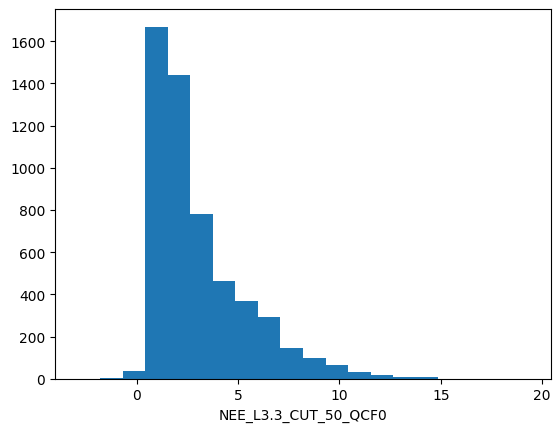

,sw_in,timesince_soil_preparation,timesince_harvest,timesince_sowing,ts_0.15_gfXG_lag3h,ta_roll3hmean,ta_roll6hmean,ts_0.05_gfXG_roll6hmean,ts_0.15_gfXG_roll3hmean,ts_0.15_gfXG_roll6hmean,ts_0.15_gfXG_roll9hmean,ts_0.3_gfXG_roll3hmean,wfps_0.05_gfXG_roll3hmean,wfps_0.3_gfXG_roll3hmean,wfps_0.3_gfXG_roll6hmean,...,ts_0.3_gfXG_lag6h_roll9hmean,ts_0.3_gfXG_lag9h_roll6hmean,ts_0.3_gfXG_lag9h_roll9hmean,wfps_0.05_gfXG_lag6h_roll9hmean,wfps_0.05_gfXG_lag9h_roll9hmean,wfps_0.15_gfXG_lag3h_roll6hmean,wfps_0.15_gfXG_lag3h_roll9hmean,wfps_0.3_gfXG_lag6h_roll3hmean,ts_0.3_gfXG_diff12h,wfps_0.15_gfXG_diff24h,wfps_0.3_gfXG_diff24h,timesince_fert,fert_timed,id,NEE_L3.3_CUT_50_QCF0
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-22 15:15:00,16.666667,36.0,37.0,36.0,6.869158,3.051111,3.344722,3.808606,6.952958,6.587325,6.294733,7.535279,49.258021,45.095750,45.499152,...,7.972340,7.985643,8.019989,48.130769,47.911635,56.416565,56.312963,46.609992,-0.580641,0.746184,1.700008,30.0,0.0,702,1.427440
2023-11-22 15:45:00,17.333333,36.0,37.0,36.0,6.856443,3.048333,3.221667,3.831431,7.017529,6.717360,6.394192,7.476265,49.140697,45.418975,45.462528,...,7.956867,7.977492,8.012311,48.312845,47.884838,56.426473,56.317332,46.734472,-0.636331,0.555294,1.585453,30.0,0.0,703,1.002807
2023-11-22 16:15:00,6.333333,36.0,37.0,36.0,6.836869,3.006111,3.095000,3.850656,7.147379,6.888447,6.515586,7.440422,48.948094,45.722494,45.452394,...,7.941213,7.966017,8.002130,48.466064,47.825725,56.468509,56.324692,46.470009,-0.543200,0.717598,1.026511,30.0,0.0,704,1.405169
2023-11-22 16:45:00,2.333333,36.0,37.0,36.0,6.822034,2.943889,2.986944,3.865788,7.077169,6.951568,6.557413,7.428509,48.723270,45.810814,45.424633,...,7.926071,7.956247,7.993097,48.579144,47.807564,56.469249,56.330240,46.527426,-0.496225,0.747449,0.461955,30.0,0.0,705,1.052631
2023-11-22 17:15:00,0.000000,36.0,37.0,36.0,7.054002,2.850000,2.931944,3.821170,6.983021,6.926161,6.582199,7.510834,48.646204,45.966189,45.349696,...,7.910730,7.948376,7.984716,48.663029,47.851701,56.495168,56.337492,46.665390,0.131402,0.862861,0.678603,30.0,0.0,706,1.088705
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-04 21:45:00,0.000000,60.0,23.0,60.0,19.005000,16.010556,16.562500,19.715370,18.769259,18.912593,18.830957,17.299259,47.840280,45.270769,45.373525,...,16.980679,16.969259,17.054537,48.464595,48.668348,49.884240,49.966284,45.428747,0.318334,-0.865616,-1.460515,30.0,0.0,27595,10.578562
2025-06-04 22:15:00,0.000000,60.0,23.0,60.0,18.944445,15.874444,16.175000,19.418333,18.687037,18.867731,18.834938,17.299907,47.843746,45.229770,45.367222,...,16.980710,16.955463,17.034259,48.415514,48.644536,49.868172,49.945490,45.368111,0.353332,-0.859899,-1.447001,30.0,0.0,27596,9.416519
2025-06-04 22:45:00,0.000000,60.0,23.0,60.0,18.900000,15.769444,15.917222,19.131898,18.603426,18.813750,18.829475,17.294907,47.842013,45.189285,45.350067,...,16.985123,16.946296,17.017191,48.366121,48.616728,49.852705,49.924215,45.334049,0.368333,-0.860283,-1.503494,30.0,0.0,27597,10.095010


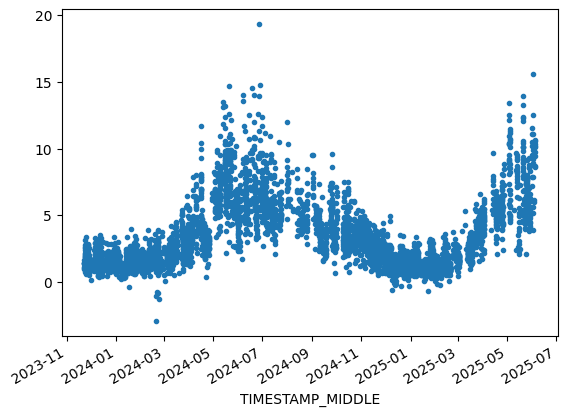

In [8]:
min_value = data[TARGET].min()

def log_transform(x):
    return np.log1p(x - min_value) if min_value < 0 else np.log1p(x)

def inverse_log_transform(x):
    return np.expm1(x) + min_value if min_value < 0 else np.expm1(x)

if LOG_TRANSFORM:
    data[TARGET] = log_transform(data[TARGET])

# Show histogram of TARGET
plt.hist(data[TARGET], bins=20)
plt.xlabel(TARGET)
plt.show()

# Show timeseries
data[TARGET].plot(x_compat=True, style='.');

data

# CROSS-VAL SPLITS

Using stratified approach based on the target variable

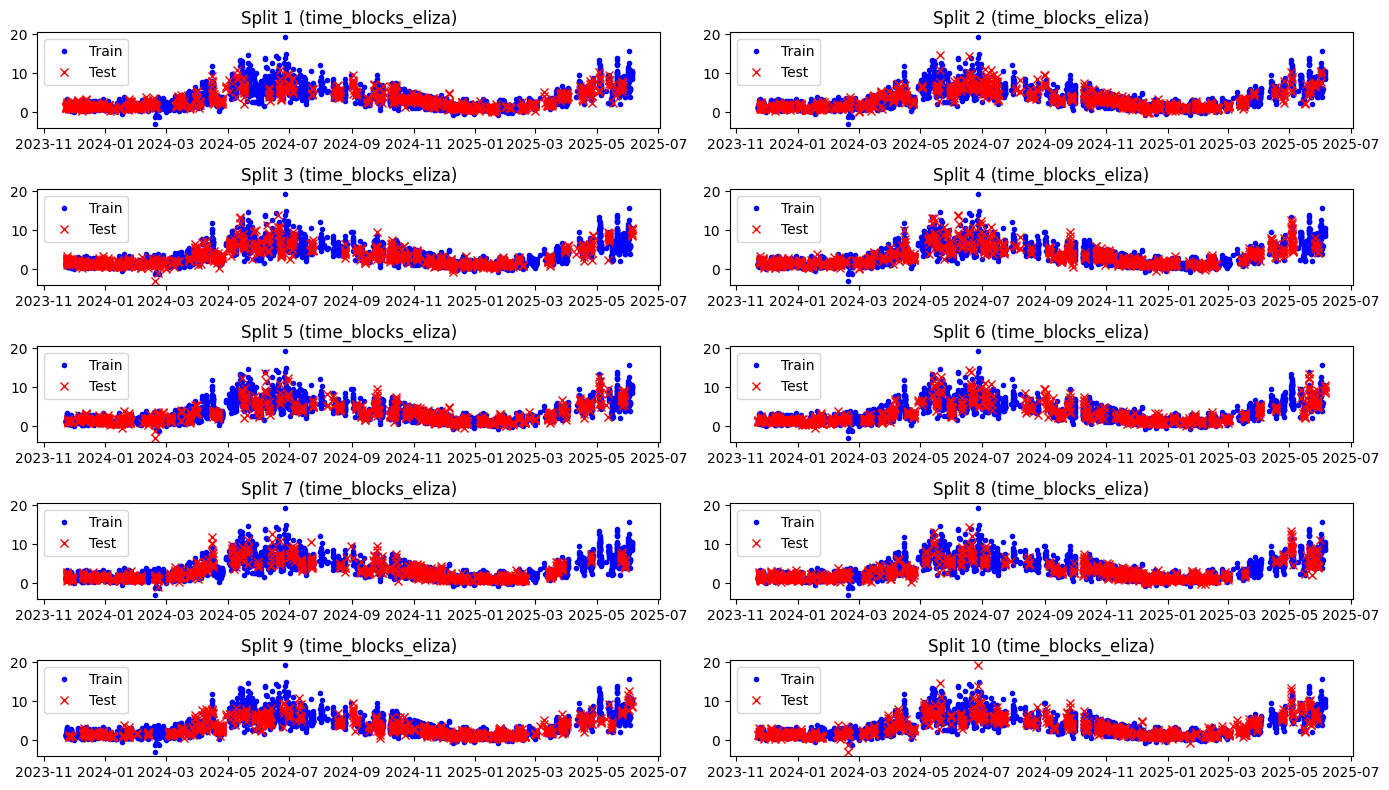

In [9]:
def create_splits(X, y, n_folds, test_size=0.2, random_state=42, n_bins=5):
    """Creates train-test splits using StratifiedShuffleSplit or StratifiedKFold with equal-width binning."""
    
    # Use pd.cut to create equal-width bins (avoids empty bins issue)
    y_binned = pd.cut(y, bins=n_bins, labels=False, include_lowest=True)

    # Select method for stratified splitting
    if CROSSVAL_SPLIT == "shuffle":
        splitter = StratifiedShuffleSplit(n_splits=n_folds, test_size=test_size, random_state=random_state)
    elif CROSSVAL_SPLIT == "kfold":
        splitter = StratifiedKFold(n_splits=n_folds, shuffle=False)

    # Generate train-test splits
    splits = [(train_idx, test_idx) for train_idx, test_idx in splitter.split(X, y_binned)]

    return splits

if CROSSVAL_SPLIT == 'time_blocks_eliza':
    def create_splits(X, y, n_folds, split=0.2, mean_block = 6, min_block=1, random_state=42): # you can set mean block to median_nan_size
        """Generates multiple train-test index splits using block-based cross-validation by varying the random seed."""
        splits = []
        total_test = round(len(X) * split)
        n_blocks = round(total_test/mean_block)

        if mean_block < min_block:
            raise ValueError("Min block size is too large for the number of blocks.")

        for fold in range(n_folds):
            np.random.seed(random_state + fold)  # Change seed for each fold
            
            tt = np.zeros(len(X))  # Array to store train-test assignments

            # Generate random block sizes with normal variation
            blocks = np.array([max(min_block, mean_block + round(v)) 
                            for v in np.random.normal(0, mean_block / 10, n_blocks)])

            # Randomly shuffle the starting positions of test blocks
            available_positions = np.arange(len(X))  # Possible start positions
            np.random.shuffle(available_positions)   # Shuffle them

            # Assign blocks sequentially based on shuffled positions
            assigned = set()
            for b in blocks:
                if len(assigned) >= total_test:
                    break
                # Pick a random starting position
                istart = np.random.choice(available_positions)
                iend = min(istart + int(b), len(X))

                # Ensure blocks don't overlap significantly
                assigned.update(range(istart, iend))
                tt[istart:iend] = 1

            train_idx = np.where(tt == 0)[0]
            test_idx = np.where(tt == 1)[0]
            
            splits.append((train_idx, test_idx))

        return splits
    
if CROSSVAL_SPLIT == 'custom_time_blocks':
    def create_splits(X, y, n_folds=5, test_fraction=0.2, block_duration='1D',
                    min_gap='6D', buffer_gap='1D', seed=None):
        """
        Time-block CV with buffer and min_gap enforcement, allowing partial blocks to match test_fraction.
        """
        if seed is not None:
            np.random.seed(seed)

        total_rows = len(X)
        total_test_target = int(total_rows * test_fraction)
        all_times = X.index
        block_dur = pd.to_timedelta(block_duration)
        min_gap_dur = pd.to_timedelta(min_gap)
        buffer_gap_dur = pd.to_timedelta(buffer_gap)

        # Generate all possible block start times
        possible_starts = all_times[(all_times + block_dur) <= all_times[-1]]
        splits = []

        for fold in range(n_folds):
            test_indices = set()
            buffer_indices = set()
            selected_blocks = []

            shuffled_starts = np.random.permutation(possible_starts)

            for start_time in shuffled_starts:
                end_time = start_time + block_dur
                buffer_start = start_time - buffer_gap_dur
                buffer_end = end_time + buffer_gap_dur

                # Enforce min_gap between selected test blocks
                if any(abs(pd.Timedelta(start_time - sel).total_seconds()) < min_gap_dur.total_seconds()
                    for sel in selected_blocks):
                    continue

                block_mask = (all_times >= start_time) & (all_times < end_time)
                buffer_mask = (all_times >= buffer_start) & (all_times < buffer_end)

                block_idx = np.where(block_mask)[0]
                buffer_idx = np.where(buffer_mask)[0]

                if len(block_idx) == 0:
                    continue

                # Allow trimming final block if needed
                remaining = total_test_target - len(test_indices)
                if remaining <= 0:
                    break
                if len(block_idx) > remaining:
                    block_idx = block_idx[:remaining]

                # Check again for overlap with buffer
                if any(i in buffer_indices for i in block_idx):
                    continue

                test_indices.update(block_idx)
                buffer_indices.update(buffer_idx)
                selected_blocks.append(start_time)

                if len(test_indices) >= total_test_target:
                    break

            train_indices = sorted(set(range(total_rows)) - test_indices - buffer_indices)
            splits.append((np.array(train_indices), np.array(sorted(test_indices))))

        return splits

X = data.drop(columns=TARGET)
y = data[TARGET]
# Create the splits using StratifiedShuffleSplit
cross_val_splits = create_splits(X, y, n_folds=N_FOLDS)


# --- PLOT TRAIN-TEST SPLITS ---
n_rows = math.ceil(N_FOLDS / 2)  # Ensure enough rows for all splits
fig, axes = plt.subplots(n_rows, 2, figsize=(14, 8))
axes = axes.flatten()  # Flatten the axes array to make iteration easier

for i, (train_idx, test_idx) in enumerate(cross_val_splits):
    train_idx_mapped = X.iloc[train_idx].index
    test_idx_mapped = X.iloc[test_idx].index

    # Plot train and test points
    axes[i].plot(y.loc[train_idx_mapped].index, y.loc[train_idx_mapped], '.', label='Train', color="blue")
    axes[i].plot(y.loc[test_idx_mapped].index, y.loc[test_idx_mapped], 'x', label='Test', color="red")
    
    axes[i].set_title(f"Split {i + 1} ({CROSSVAL_SPLIT})")
    axes[i].legend()

# Hide unused subplots if n_folds is odd
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# HYPERPARAMETER TUNING

In [10]:
# Convert cross-val splits into PredefinedSplit format to be able to use them in GridSearchCV
test_fold = np.full(len(data), -1)  # Initialize with -1 (all as training)
for fold_idx, (train_idx, test_idx) in enumerate(cross_val_splits):
    test_fold[test_idx] = fold_idx  # Assign test samples to a specific fold
predefined_cv = PredefinedSplit(test_fold)

param_grids = {
    'RandomForest': {
        'n_estimators': [50, 100, 300, 500], # Similar to XGBoost
        'max_depth': [3, 5, 10, 15], # Controls tree depth
        'min_samples_split': [2, 5, 10], # Similar to min_child_weight
        'min_samples_leaf': [1, 3, 5], # Controls leaf size
        'max_features': [0.4, 0.6, 0.8, 1.0], # Similar to colsample_bytree
    },
    'XGBoost': {
        'n_estimators': [50, 100, 300, 500],
        'gamma': [0, 0.2, 0.4],
        'max_depth': [3, 5, 10, 15],
        'learning_rate': [0.001, 0.005, 0.01, 0.05],
        'subsample': [0.65, 0.75, 1],
        'colsample_bytree': [0.4, 0.6, 0.8, 1],
        'min_child_weight': [2, 5, 10]
    }
}

model_class = RandomForestRegressor if MODEL_TYPE == 'RandomForest' else XGBRegressor
param_grid = param_grids[MODEL_TYPE]
model = model_class(random_state=42)
grid_search = GridSearchCV(model, param_grid, cv=predefined_cv, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(data[selected_features], data[TARGET])

print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'colsample_bytree': 1, 'gamma': 0, 'learning_rate': 0.01, 'max_depth': 10, 'min_child_weight': 10, 'n_estimators': 500, 'subsample': 0.65}


# EXPORT 

In [11]:
filename = 'best_hyperparameters_' + TARGET_FLUX + '_' + DAY_NIGHT + '_' + MODEL_TYPE + '.json'
with open(filename, "w") as f:
    json.dump(grid_search.best_params_, f)

# **End of notebook**

In [12]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished {dt_string}")

Finished 2025-10-25 08:55:49
